In [1]:
# Cell 1 — Load champion model
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, roc_curve
)
from ml_pipeline.training.registry import LocalFileRegistry
from ml_pipeline.training.dataset import build_training_dataset

registry = LocalFileRegistry()
model, metadata = registry.load("current")
X, y, groups = build_training_dataset()

# Same split as training — reproducible
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= metadata.threshold).astype(int)

print(f"Model version:  {metadata.version}")
print(f"Threshold:      {metadata.threshold}")
print(f"Test set size:  {len(X_test):,}")
print(f"Fraud in test:  {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

  Dataset: 43,576 rows | Fraud: 6,789 (15.6%) | Features: 12
Model version:  v20260326_2026
Threshold:      0.89
Test set size:  6,537
Fraud in test:  1,018 (15.6%)


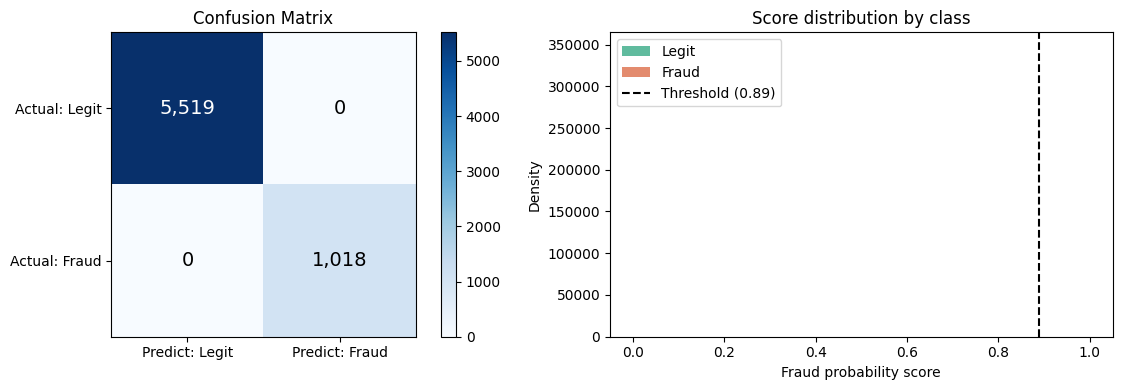


True  Negatives (correctly allowed):  5,519
False Positives (legit blocked):       0  ← false alarm, hurts UX
False Negatives (fraud missed):        0  ← fraud got through
True  Positives (fraud caught):        1,018

False positive rate: 0.00%
False negative rate: 0.00%


In [2]:
# Cell 2 — Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Predict: Legit", "Predict: Fraud"])
axes[0].set_yticklabels(["Actual: Legit", "Actual: Fraud"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                     fontsize=14, color="white" if cm[i,j] > cm.max()/2 else "black")
axes[0].set_title("Confusion Matrix")
plt.colorbar(im, ax=axes[0])

# Score distribution
axes[1].hist(y_prob[y_test==0], bins=50, color="#1D9E75",
             alpha=0.7, label="Legit", density=True)
axes[1].hist(y_prob[y_test==1], bins=50, color="#D85A30",
             alpha=0.7, label="Fraud", density=True)
axes[1].axvline(metadata.threshold, color="black", linestyle="--",
                label=f"Threshold ({metadata.threshold})")
axes[1].set_xlabel("Fraud probability score")
axes[1].set_ylabel("Density")
axes[1].set_title("Score distribution by class")
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpret the matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (correctly allowed):  {tn:,}")
print(f"False Positives (legit blocked):       {fp:,}  ← false alarm, hurts UX")
print(f"False Negatives (fraud missed):        {fn:,}  ← fraud got through")
print(f"True  Positives (fraud caught):        {tp:,}")
print(f"\nFalse positive rate: {fp/(fp+tn)*100:.2f}%")
print(f"False negative rate: {fn/(fn+tp)*100:.2f}%")

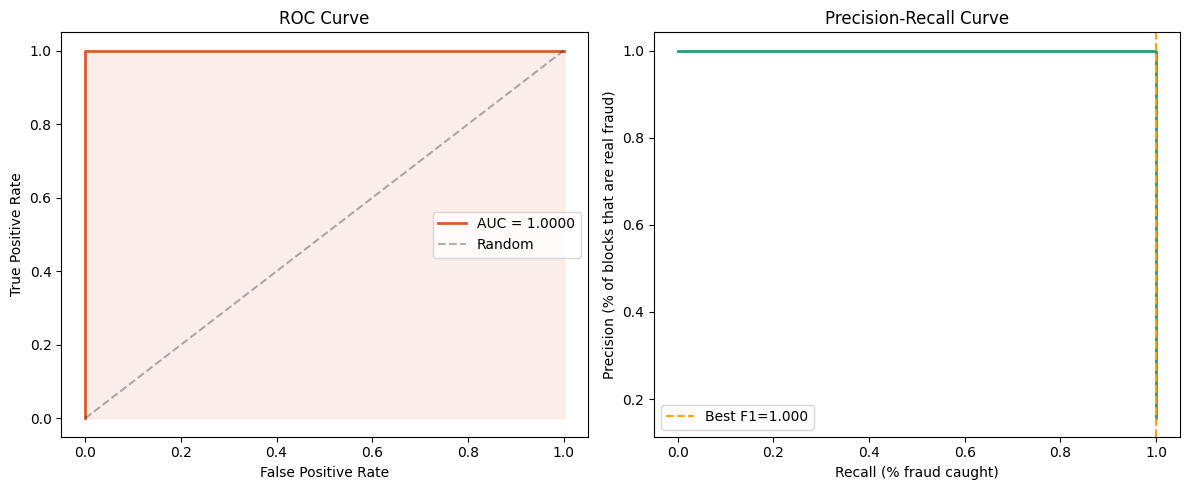


Business tradeoff:
  High threshold → fewer false positives (customers not blocked unfairly)
                  → more false negatives (fraud gets through)
  Low threshold  → more fraud caught
                  → more legitimate customers blocked (bad for UX)

Current threshold: 0.89 — balanced for this synthetic data


In [3]:
# Cell 3 — ROC curve + PR curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color="#D85A30", lw=2, label=f"AUC = {auc:.4f}")
axes[0].plot([0,1],[0,1], "k--", alpha=0.3, label="Random")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#D85A30")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2*(precisions*recalls)/(precisions+recalls+1e-8)
axes[1].plot(recalls, precisions, color="#1D9E75", lw=2)
axes[1].axvline(recalls[np.argmax(f1_scores)], color="orange",
                linestyle="--", label=f"Best F1={f1_scores.max():.3f}")
axes[1].set_xlabel("Recall (% fraud caught)")
axes[1].set_ylabel("Precision (% of blocks that are real fraud)")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

# The business tradeoff
print("\nBusiness tradeoff:")
print("  High threshold → fewer false positives (customers not blocked unfairly)")
print("                  → more false negatives (fraud gets through)")
print("  Low threshold  → more fraud caught")
print("                  → more legitimate customers blocked (bad for UX)")
print(f"\nCurrent threshold: {metadata.threshold} — balanced for this synthetic data")

c:\Users\Swateya Gupta\Downloads\fraudshield_mvp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


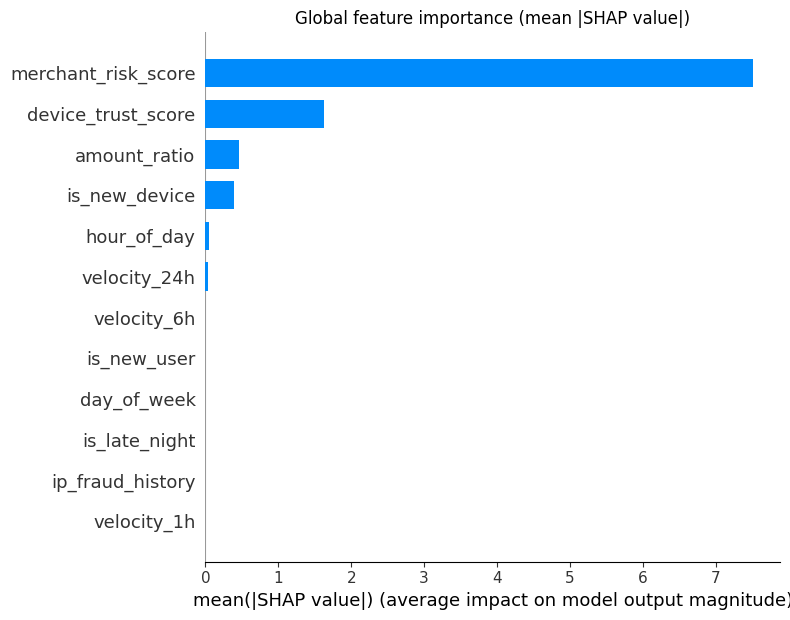

In [4]:
# Cell 4 — SHAP: why did the model make each decision?
import shap

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot — feature importance globally
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type="bar", show=False)
plt.title("Global feature importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

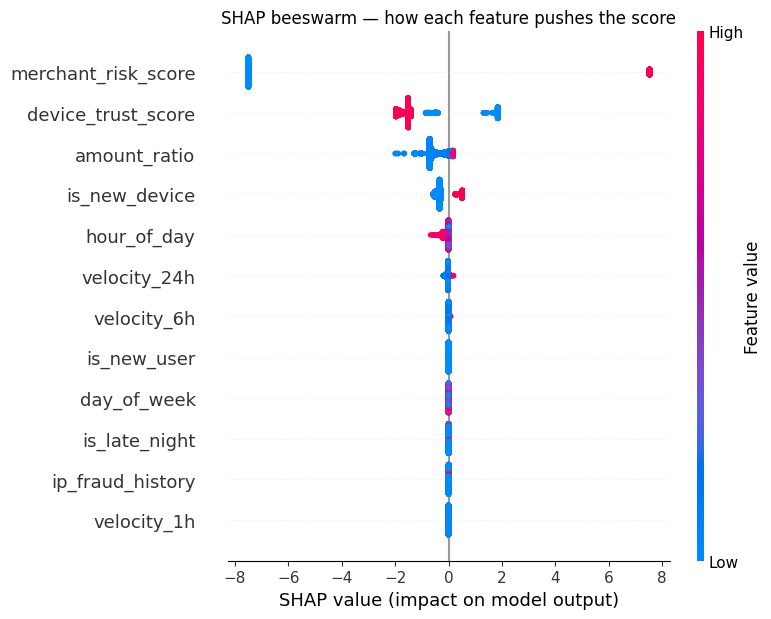


How to read this plot:
  Each dot = one transaction
  Red dot = high feature value, Blue dot = low feature value
  Dot position on X axis = how much it pushed toward fraud (right) or legit (left)

  Example: ip_fraud_history
    Red dots (ip_fraud_history=1.0) pushed far RIGHT → toward fraud
    Blue dots (ip_fraud_history=0.0) pushed far LEFT → toward legit
    → This feature has strong directional impact



In [5]:
# Cell 5 — SHAP beeswarm: direction of each feature's impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title("SHAP beeswarm — how each feature pushes the score")
plt.tight_layout()
plt.show()

print("""
How to read this plot:
  Each dot = one transaction
  Red dot = high feature value, Blue dot = low feature value
  Dot position on X axis = how much it pushed toward fraud (right) or legit (left)

  Example: ip_fraud_history
    Red dots (ip_fraud_history=1.0) pushed far RIGHT → toward fraud
    Blue dots (ip_fraud_history=0.0) pushed far LEFT → toward legit
    → This feature has strong directional impact
""")

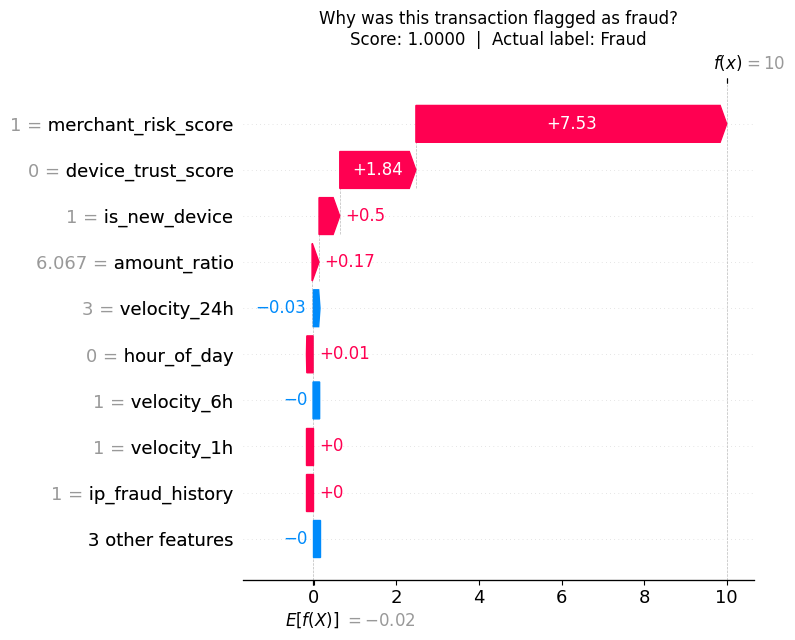


Feature values for this transaction:
  velocity_1h               1.0000
  velocity_6h               1.0000
  velocity_24h              3.0000
  amount_ratio              6.0665
  device_trust_score        0.0000
  ip_fraud_history          1.0000
  merchant_risk_score       1.0000
  hour_of_day               0.0000
  day_of_week               5.0000
  is_new_device             1.0000
  is_late_night             1.0000
  is_new_user               0.0000


In [6]:
# Cell 6 — SHAP waterfall: explain ONE transaction decision
# Pick a high-scoring fraud transaction
fraud_idx   = X_test[y_test == 1].index[0]
fraud_pos   = X_test.index.get_loc(fraud_idx)

shap_exp = shap.Explanation(
    values    = shap_values[fraud_pos],
    base_values = explainer.expected_value,
    data      = X_test.iloc[fraud_pos].values,
    feature_names = X.columns.tolist()
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f"Why was this transaction flagged as fraud?\n"
          f"Score: {y_prob[fraud_pos]:.4f}  |  "
          f"Actual label: {'Fraud' if y_test.iloc[fraud_pos] else 'Legit'}")
plt.tight_layout()
plt.show()

print("\nFeature values for this transaction:")
for feat, val in zip(X.columns, X_test.iloc[fraud_pos]):
    print(f"  {feat:<25} {val:.4f}")

       version  auc_roc  precision  recall     f1  threshold   champion
v20260324_1928   0.6806     0.1593  0.4248 0.2317     0.4693           
v20260325_0741   0.6699     0.2966  0.2318 0.2602     0.6841           
v20260325_2108   1.0000     1.0000  1.0000 1.0000     0.9977           
v20260326_0746   1.0000     1.0000  1.0000 1.0000     0.9998           
v20260326_0801   1.0000     1.0000  1.0000 1.0000     0.8900           
v20260326_1912   1.0000     1.0000  1.0000 1.0000     0.8900           
v20260326_1948   1.0000     1.0000  1.0000 1.0000     0.8900           
v20260326_1959   1.0000     1.0000  1.0000 1.0000     0.8900           
v20260326_2026   1.0000     1.0000  1.0000 1.0000     0.8900 ← CHAMPION


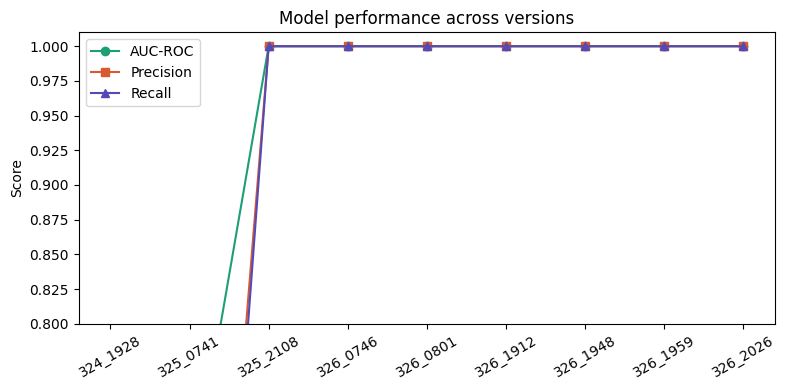

In [7]:
# Cell 7 — Model registry: compare all versions
from ml_pipeline.training.registry import LocalFileRegistry

registry = LocalFileRegistry()
versions = registry.list_versions()

if len(versions) > 1:
    comparison = pd.DataFrame([{
        "version":   v.version,
        "auc_roc":   v.auc_roc,
        "precision": v.precision,
        "recall":    v.recall,
        "f1":        v.f1_score,
        "threshold": v.threshold,
        "champion":  "← CHAMPION" if v.is_champion else "",
    } for v in versions])
    print(comparison.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(versions))
    ax.plot(x, [v.auc_roc   for v in versions], "o-", label="AUC-ROC", color="#1D9E75")
    ax.plot(x, [v.precision for v in versions], "s-", label="Precision", color="#D85A30")
    ax.plot(x, [v.recall    for v in versions], "^-", label="Recall", color="#534AB7")
    ax.set_xticks(list(x))
    ax.set_xticklabels([v.version[-8:] for v in versions], rotation=30)
    ax.set_ylabel("Score")
    ax.set_title("Model performance across versions")
    ax.legend()
    ax.set_ylim(0.8, 1.01)
    plt.tight_layout()
    plt.show()
else:
    print(f"Only one version: {versions[0].version}")
    print(f"AUC={versions[0].auc_roc}  Precision={versions[0].precision}  Recall={versions[0].recall}")
    print("\nTrain more versions by running train_model.py after injecting drift")

In [8]:
# Cell 8 — Final summary
print("=" * 55)
print("MODEL EVALUATION SUMMARY")
print("=" * 55)
print(f"\nModel:      {metadata.version}")
print(f"Test rows:  {len(X_test):,}")
print(f"Fraud rows: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print(f"\nMetrics at threshold {metadata.threshold}:")
print(classification_report(y_test, y_pred,
                             target_names=["Legit","Fraud"],
                             digits=4))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Business impact:")
print(f"  Fraud blocked correctly:    {tp:,}")
print(f"  Fraud missed:               {fn:,}")
print(f"  Legit customers blocked:    {fp:,}")
print(f"  False positive rate:        {fp/(fp+tn)*100:.2f}%")
print(f"  Savings (assume avg ₹10k):  ₹{tp*10000:,.0f}")
print("=" * 55)

MODEL EVALUATION SUMMARY

Model:      v20260326_2026
Test rows:  6,537
Fraud rows: 1,018 (15.6%)

Metrics at threshold 0.89:
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000      5519
       Fraud     1.0000    1.0000    1.0000      1018

    accuracy                         1.0000      6537
   macro avg     1.0000    1.0000    1.0000      6537
weighted avg     1.0000    1.0000    1.0000      6537

Business impact:
  Fraud blocked correctly:    1,018
  Fraud missed:               0
  Legit customers blocked:    0
  False positive rate:        0.00%
  Savings (assume avg ₹10k):  ₹10,180,000
